In [49]:
import zipfile
import os

zip_path = "/content/archive (2).zip"
extract_path = "/content/news_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


# Fake News Detection Using Machine Learning

This project detects whether a news article is Fake or Real using Machine Learning and Natural Language Processing.

In [3]:
import os
os.listdir("news_data")

['News _dataset']

## 1. Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Loading the Dataset

In [50]:
fake = pd.read_csv("news_data/News _dataset/Fake.csv")
true = pd.read_csv("news_data/News _dataset/True.csv")

print("Fake news:", fake.shape)
print("True news:", true.shape)

Fake news: (23481, 4)
True news: (21417, 4)


In [6]:
fake = pd.read_csv("news_data/News _dataset/Fake.csv")
true = pd.read_csv("news_data/News _dataset/True.csv")

In [7]:
print("Fake News:")
display(fake.head())

print("Real News:")
display(true.head())

Fake News:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


Real News:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


## 3. Exploring the Dataset

In [8]:
print("Fake columns:")
print(fake.columns)

print("\nReal columns:")
print(true.columns)

Fake columns:
Index(['title', 'text', 'subject', 'date'], dtype='object')

Real columns:
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [9]:
print("Fake News Shape:", fake.shape)
print("Real News Shape:", true.shape)

Fake News Shape: (23481, 4)
Real News Shape: (21417, 4)


In [10]:
print("Missing values in Fake News:")
print(fake.isnull().sum())

print("\nMissing values in Real News:")
print(true.isnull().sum())

Missing values in Fake News:
title      0
text       0
subject    0
date       0
dtype: int64

Missing values in Real News:
title      0
text       0
subject    0
date       0
dtype: int64


## 4. Data Preparation

In [11]:
fake['label'] = 0
true['label'] = 1

In [12]:
data = pd.concat([fake, true], ignore_index=True)

In [13]:
print("Dataset shape:", data.shape)
print("\nLabel distribution:")
print(data['label'].value_counts())

Dataset shape: (44898, 5)

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64


In [15]:
data['content'] = data['title'] + " " + data['text']

In [16]:
print(data[['content', 'label']].head())

                                             content  label
0   Donald Trump Sends Out Embarrassing New Year’...      0
1   Drunk Bragging Trump Staffer Started Russian ...      0
2   Sheriff David Clarke Becomes An Internet Joke...      0
3   Trump Is So Obsessed He Even Has Obama’s Name...      0
4   Pope Francis Just Called Out Donald Trump Dur...      0


In [17]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['clean_content'] = data['content'].apply(clean_text)

In [18]:
print(data[['content', 'clean_content']].head(2))

                                             content  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   

                                       clean_content  
0  donald trump sends out embarrassing new years ...  
1  drunk bragging trump staffer started russian c...  


In [19]:
X = data['clean_content']
y = data['label']


## 5. Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (35918,)
Testing data: (8980,)


## 6. TF-IDF Feature Extraction

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
vectorizer = TfidfVectorizer(max_features=5000)

In [26]:
vectorizer.fit_transform(X_train)



<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6176006 stored elements and shape (35918, 5000)>

In [27]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [29]:
X_test_tfidf = vectorizer.transform(X_test)

In [30]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (35918, 5000)
Testing TF-IDF shape: (8980, 5000)


## 7. Logistic Regression Model

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
model = LogisticRegression(max_iter=1000)

In [33]:
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred = model.predict(X_test_tfidf)

In [35]:
print("Actual labels:   ", y_test.values[:10])
print("Predicted labels:", y_pred[:10])

Actual labels:    [1 1 0 1 1 0 1 0 1 1]
Predicted labels: [1 1 0 1 1 0 1 0 1 1]


## 8. Model Evaluation

In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9896436525612472
Accuracy (%): 98.96436525612472


## 9. Confusion Matrix

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4635   61]
 [  32 4252]]


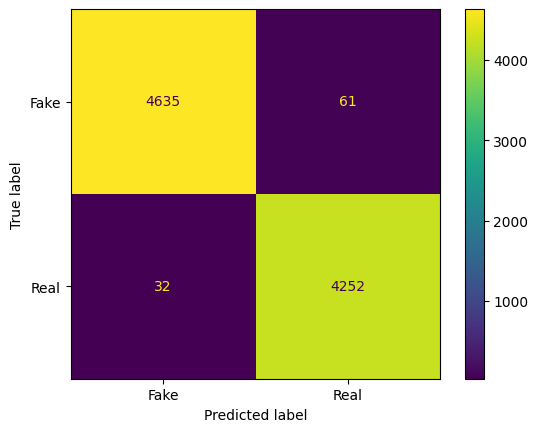

In [38]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.show()

In [39]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "Real"]
))

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [40]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "Real"]
))

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



## 11. New News Prediction

The trained model can also predict whether a new news article is Fake or Real.

In [41]:
def predict_news(title, text):

    news = title + " " + text

    news_tfidf = vectorizer.transform([news])

    prediction = model.predict(news_tfidf)[0]

    if prediction == 0:
        return "FAKE NEWS"
    else:
        return "REAL NEWS"

In [43]:
title = input("Enter news title: ")
text = input("Enter news text: ")

result = predict_news(title, text)

print("\nPrediction:", result)

Enter news title: Government announces new education policy
Enter news text: The government announced a new education policy today. The policy aims to improve access to education and introduce new learning opportunities for students.

Prediction: FAKE NEWS


In [44]:
sample = data.iloc[100]

print("Title:")
print(sample['title'])

print("\nActual label:")
print("FAKE" if sample['label'] == 0 else "REAL")

print("\nModel prediction:")
print(predict_news(sample['title'], sample['text']))

Title:
 Watch: Joe Biden Just Wrecked Trump In Six Words And It’s Hilarious

Actual label:
FAKE

Model prediction:
FAKE NEWS
